# Parcial 1 - Clasificacion de Tipos de Flores

**Objetivo:** construir un modelo de vision artificial (CNN) para clasificar imagenes del dataset `flower_photos` y dejar listos los artefactos para despliegue en Streamlit.

In [7]:
# Librerias base para manejo de datos, visualizacion y deep learning
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers
from sklearn.metrics import classification_report, confusion_matrix

# Semillas para resultados mas reproducibles
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


En esta celda se importan las herramientas necesarias y se fija una semilla para mejorar la reproducibilidad del entrenamiento. Si no hay errores, el entorno esta listo para continuar.

## Carga del Dataset

In [8]:
# Cargar dataset desde Google Drive (Colab) o desde ruta local
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data_dir = Path('/content/drive/MyDrive/Ciencia_de_Datos/flower_photos')
except Exception:
    # Fallback para ejecucion local
    data_dir = Path('flower_photos')

assert data_dir.exists(), f'No se encontro la carpeta: {data_dir}'

# Parametros del pipeline de entrada
img_height, img_width = 180, 180
batch_size = 32
val_split = 0.3

# Dataset de entrenamiento (70%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=val_split,
    subset='training',
    seed=SEED,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Dataset temporal (30%) para luego dividirlo en val/test
full_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=val_split,
    subset='validation',
    seed=SEED,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Dividir ese 30% en 15% validacion y 15% prueba
val_batches = tf.data.experimental.cardinality(full_val_ds).numpy()
val_ds = full_val_ds.take(val_batches // 2)
test_ds = full_val_ds.skip(val_batches // 2)

# Etiquetas desde los nombres de carpetas
class_names = train_ds.class_names
num_classes = len(class_names)

print('Clases detectadas:', class_names)
print('Numero de clases:', num_classes)

Mounted at /content/drive
Found 3670 files belonging to 5 classes.
Using 2569 files for training.
Found 3670 files belonging to 5 classes.
Using 1101 files for validation.
Clases detectadas: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Numero de clases: 5


Aqui se crean tres subconjuntos desde `MyDrive/Ciencia de datos/flower_photos`: entrenamiento, validacion y prueba. Las etiquetas provienen de los nombres de subcarpetas y se guardan en `class_names` para mantener consistencia durante todo el flujo.

## Exploracion Visual del Dataset

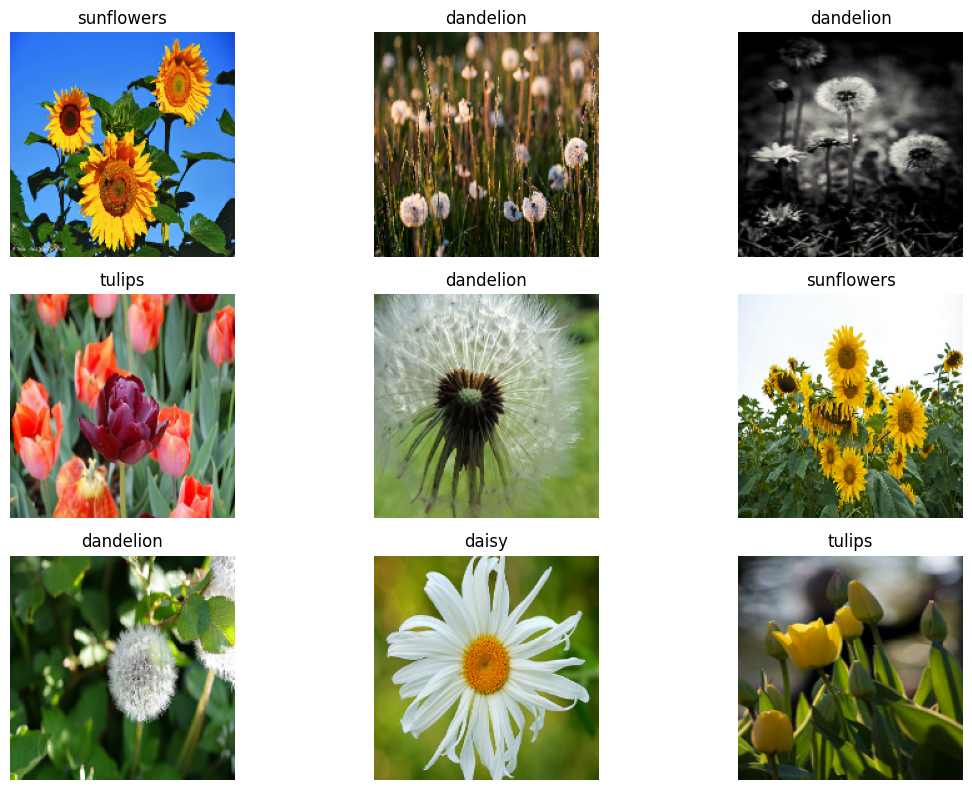

In [3]:
# Visualizar un lote de imagenes para inspeccion rapida de calidad y etiquetas
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

Esta inspeccion permite validar que las imagenes se cargan correctamente y que la etiqueta coincide con el contenido visual. Es un control antes del entrenamiento para detectar errores de organizacion en carpetas o ruido excesivo.

## Preprocesamiento y Rendimiento del Pipeline

In [ ]:
# Convertir datasets a arreglos numpy para un flujo mas simple
def dataset_to_numpy(ds):
    x_batches, y_batches = [], []
    for images, labels in ds:
        x_batches.append(images.numpy())
        y_batches.append(labels.numpy())
    x = np.concatenate(x_batches, axis=0).astype('float32')
    y = np.concatenate(y_batches, axis=0).astype('int32')
    return x, y

x_train, y_train = dataset_to_numpy(train_ds)
x_val, y_val = dataset_to_numpy(val_ds)
x_test, y_test = dataset_to_numpy(test_ds)

print('Tamano de imagen de entrenamiento (alto, ancho):', (x_train.shape[1], x_train.shape[2]))
print('Primera etiqueta (y_train[0]):', class_names[y_train[0]])

# Normalizacion estilo Taller 3: [0, 255] -> [0, 1]
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Verificar cardinalidad de etiquetas
y_train_unique = np.unique(y_train)
print('Valores unicos en y_train:', y_train_unique)
print('Cardinalidad de y_train:', len(y_train_unique))

# One-hot encoding
from tensorflow.keras.utils import to_categorical
y_train_categorical = to_categorical(y_train, num_classes)
y_val_categorical = to_categorical(y_val, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)
print('Shape x_train:', x_train.shape)
print('Shape y_train_categorical:', y_train_categorical.shape)

En este flujo se convierten los datasets a arreglos `numpy`, se normalizan las imagenes de `[0, 255]` a `[0, 1]`, y se aplica one-hot encoding para entrenar con `categorical_crossentropy` en un esquema mas simple.

## Construccion del Modelo CNN

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

# Construccion de la red convolucional (estilo Taller 3)
input_layer = Input(shape=(img_height, img_width, 3))

conv1 = Conv2D(64, kernel_size=(3, 3), activation='relu')(input_layer)
pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

conv2 = Conv2D(32, kernel_size=(3, 3), activation='relu')(pool1)
pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

flatten = Flatten()(pool2)
dense = Dense(64, activation='relu')(flatten)
output = Dense(num_classes, activation='softmax')(dense)

model = Model(inputs=input_layer, outputs=output)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,877 (30.61 MB)

 Trainable params: 8,023,877 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

Se utiliza una CNN con bloques Conv2D + MaxPooling para extraer patrones morfologicos (petalos, textura, forma). Las capas `Dropout` ayudan a reducir sobreajuste y la salida `softmax` permite obtener distribucion de probabilidades por clase.

## Compilacion y Entrenamiento

In [ ]:
# Compilar y entrenar (igual al enfoque simplificado)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train,
    y_train_categorical,
    epochs=30,
    validation_data=(x_val, y_val_categorical),
    batch_size=32,
    verbose=1
)

print('Entrenamiento finalizado.')

Epoch 1/20
 6/81 ━━━━━━━━━━━━━━━━━━━━ 5:01 4s/step - accuracy: 0.2529 - loss: 185.5770

KeyboardInterrupt: 

En esta etapa el modelo aprende a separar clases de flores. Si `val_accuracy` sube y `val_loss` baja de forma estable, el comportamiento es sano. Si hay gran brecha entre entrenamiento y validacion, podria existir sobreajuste.

## Evaluacion Cuantitativa

In [ ]:
# Metricas globales en validacion y prueba
val_loss, val_accuracy = model.evaluate(x_val, y_val_categorical, verbose=0)
test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical, verbose=0)
print(f'Val loss: {val_loss:.4f}')
print(f'Val accuracy: {val_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

# Curvas de aprendizaje para analizar estabilidad del entrenamiento
hist = history.history
epochs_range = range(1, len(hist['loss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist['loss'], label='Train Loss')
plt.plot(epochs_range, hist['val_loss'], label='Val Loss')
plt.title('Loss por epoca')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist['accuracy'], label='Train Acc')
plt.plot(epochs_range, hist['val_accuracy'], label='Val Acc')
plt.title('Accuracy por epoca')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

El valor de accuracy resume el desempeno general, mientras que las curvas permiten ver la dinamica del entrenamiento. Un comportamiento deseable es convergencia sin oscilaciones fuertes y sin separacion extrema entre train/val.

## Matriz de Confusion y Reporte por Clase

In [ ]:
# Recolectar etiquetas reales y predichas para analisis por clase en TEST
y_true = y_test
y_pred_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Matriz de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusion - Test')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Reporte detallado por clase
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Esta salida permite identificar clases con mayor confusion. El reporte de precision, recall y F1 por clase facilita justificar decisiones de mejora (mas datos por clase, augmentation adicional o ajuste de arquitectura).

## Guardado de Artefactos para Despliegue

In [ ]:
# Crear carpeta de salida para artefactos del modelo
artifacts_dir = Path('artefactos_parcial1')
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Guardar modelo final
model_path = artifacts_dir / 'flower_classifier.keras'
model.save(model_path)

# Guardar clases en JSON para consumirlas facilmente desde Streamlit
classes_path = artifacts_dir / 'class_names.json'
with open(classes_path, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

print('Modelo guardado en:', model_path.resolve())
print('Clases guardadas en:', classes_path.resolve())

Con estos archivos (`flower_classifier.keras` y `class_names.json`) queda preparada la base para una app interactiva en Streamlit: carga de imagen, listado de clases y visualizacion de probabilidades por clase.

## Prueba de Inferencia con Distribucion de Probabilidades

In [ ]:
# Tomar una imagen del set de validacion para simular carga de usuario en app
sample_image = x_val[0]

# El modelo retorna la distribucion completa de probabilidades
probs = model.predict(np.expand_dims(sample_image, axis=0), verbose=0)[0]
pred_idx = int(np.argmax(probs))
pred_class = class_names[pred_idx]

# Visualizar imagen y clase mas probable
plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f'Prediccion: {pred_class}')
plt.axis('off')
plt.show()

# Grafico de probabilidades por clase con resaltado del maximo
colors = ['#90caf9'] * len(class_names)
colors[pred_idx] = '#ff8a65'

plt.figure(figsize=(10, 4))
bars = plt.bar(class_names, probs, color=colors)
plt.title('Distribucion de probabilidades por clase')
plt.ylabel('Probabilidad')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

for bar, p in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width() / 2, p + 0.01, f'{p:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('Clase mas probable:', pred_class)

Este bloque replica exactamente la logica requerida para la app interactiva: una imagen de entrada, catalogo de clases, distribucion de probabilidades y resaltado automatico de la clase ganadora.

## Conclusiones de la Primera Parte

Se desarrollo el cuaderno de extremo a extremo para clasificacion de flores con CNN, incluyendo preparacion de datos, entrenamiento, evaluacion y generacion de artefactos para despliegue. Con esto queda lista la base para la segunda parte: implementacion de la interfaz en Streamlit.